# Autocorrelation of Cow Slaughter Data

Examine the temporal autocorrelation structure of weekly cattle slaughter counts for USDA Regions 4 (Southeast) and 6 (South Central). This helps identify:
- Seasonal patterns (lags at ~52 weeks)
- Short-term persistence (consecutive weeks correlated)
- Appropriate lag structures for predictive modeling

In [1]:
import sys
sys.path.insert(0, '../..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import config
from src.data_loading import load_cattle_data

In [2]:
# Load cattle slaughter data
cattle_df = load_cattle_data(config.CATTLE_DATA_FILE)
cattle_df = cattle_df.set_index('date').sort_index()

# Compute total beef slaughter for focus regions
cattle_df['region_4_beef'] = cattle_df['region_4_beef_dairy'] - cattle_df['region_4_dairy']
cattle_df['region_6_beef'] = cattle_df['region_6_beef_dairy'] - cattle_df['region_6_dairy']

print(f"Date range: {cattle_df.index.min()} to {cattle_df.index.max()}")
print(f"Total weeks: {len(cattle_df)}")
cattle_df[['region_4_beef_dairy', 'region_4_beef', 'region_4_dairy',
           'region_6_beef_dairy', 'region_6_beef', 'region_6_dairy']].describe().round(1)

Date range: 1984-01-07 00:00:00 to 2027-03-13 00:00:00
Total weeks: 2254


,region_4_beef_dairy,region_4_beef,region_4_dairy,region_6_beef_dairy,region_6_beef,region_6_dairy
count,2193.0,2141.0,2141.0,2193.0,2193.0,2193.0
mean,13.3,9.1,4.1,19.1,14.9,4.2
std,3.4,2.5,1.8,4.8,4.3,2.1
min,5.6,3.2,1.6,4.6,3.5,0.7
25%,11.0,7.2,2.9,15.4,11.9,2.5
50%,13.0,8.8,3.6,19.0,14.4,3.2
75%,14.7,10.6,5.1,22.0,17.3,6.1
max,29.8,20.3,14.9,40.6,37.6,11.9


## ACF and PACF Plots

Autocorrelation (ACF) shows correlation at each lag including indirect effects. Partial autocorrelation (PACF) isolates the direct effect at each lag after removing shorter-lag contributions.

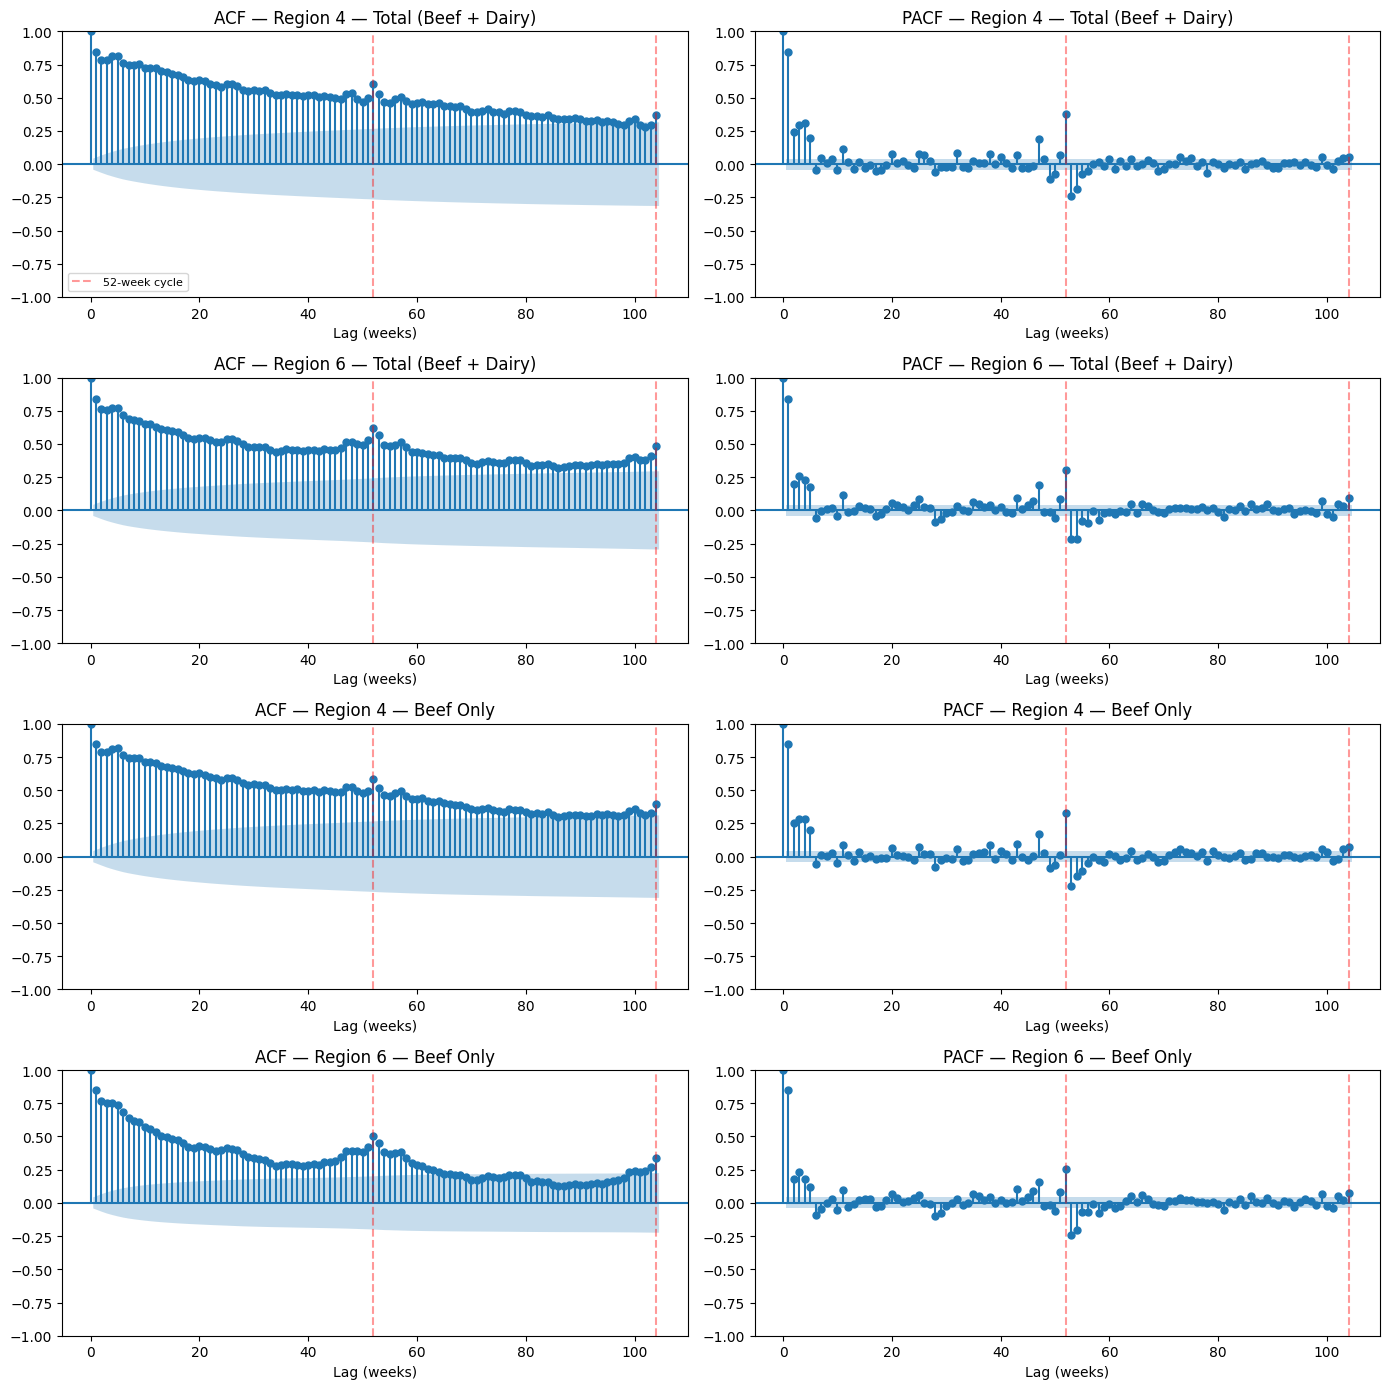

Saved to /Users/klesinger/Library/CloudStorage/GoogleDrive-kdl0040@uah.edu/My Drive/VEDA/Stories/livestock_and_heat/research/notebooks/03_analysis/../../figures/slaughter_autocorrelation.png


In [3]:
series_config = {
    'region_4_beef_dairy': ('Region 4 — Total (Beef + Dairy)', config.REGION_SHORT_NAMES['region_4']),
    'region_6_beef_dairy': ('Region 6 — Total (Beef + Dairy)', config.REGION_SHORT_NAMES['region_6']),
    'region_4_beef':       ('Region 4 — Beef Only', config.REGION_SHORT_NAMES['region_4']),
    'region_6_beef':       ('Region 6 — Beef Only', config.REGION_SHORT_NAMES['region_6']),
}

max_lag = 104  # 2 years of weekly data

fig, axes = plt.subplots(len(series_config), 2, figsize=(14, 3.5 * len(series_config)))

for i, (col, (title, region_label)) in enumerate(series_config.items()):
    series = cattle_df[col].dropna()

    plot_acf(series, lags=max_lag, ax=axes[i, 0], title=f'ACF — {title}', alpha=0.05)
    plot_pacf(series, lags=max_lag, ax=axes[i, 1], title=f'PACF — {title}', alpha=0.05, method='ywm')

    for j in range(2):
        axes[i, j].set_xlabel('Lag (weeks)')
        # Mark annual cycle
        for yr in [52, 104]:
            if yr <= max_lag:
                axes[i, j].axvline(yr, color='red', linestyle='--', alpha=0.4, label='52-week cycle' if yr == 52 else None)

axes[0, 0].legend(fontsize=8)
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / 'slaughter_autocorrelation.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to {config.FIGURES_DIR / 'slaughter_autocorrelation.png'}")

## Key Lag Correlations

Extract the ACF values at notable lags (1-4 weeks, seasonal at 26 and 52 weeks) to quantify persistence and seasonality.

In [4]:
key_lags = [1, 2, 3, 4, 8, 13, 26, 52]
rows = []

for col, (title, _) in series_config.items():
    series = cattle_df[col].dropna()
    acf_vals = acf(series, nlags=max(key_lags), fft=True)
    for lag in key_lags:
        rows.append({'Series': title, 'Lag (weeks)': lag, 'ACF': round(acf_vals[lag], 3)})

lag_table = pd.DataFrame(rows).pivot(index='Lag (weeks)', columns='Series', values='ACF')
lag_table

Series,Region 4 — Beef Only,Region 4 — Total (Beef + Dairy),Region 6 — Beef Only,Region 6 — Total (Beef + Dairy)
Lag (weeks),,,,
1,0.847,0.844,0.847,0.841
2,0.790,0.782,0.768,0.765
3,0.790,0.783,0.750,0.756
4,0.811,0.813,0.748,0.768
8,0.740,0.746,0.616,0.677
13,0.683,0.700,0.506,0.610
26,0.589,0.601,0.409,0.534
52,0.581,0.602,0.504,0.622
